<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB8 — Architecture Comparison: EHR Tabular Data — Pima Diabetes + Cleveland Heart  ·  LR vs DT vs GBM vs EBM vs MLP</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 3 | Prof. Dr. Utku Kose | Universidad Panamericana</p><p style="color:#D0E4F4;margin:2px 0 0;font-size:0.9em">Section 1: Architecture overview & design patterns  |  Section 2: Parameter sweep experiments  |  Section 3: SHAP per model  |  Section 4: Faithfulness scoring</p></div>

## Learning Objectives

After completing this notebook you will be able to:
- Choose the right architecture for structured clinical tabular data based on interpretability requirements
- Understand **why architecture and XAI method must be selected jointly** (Module 3, Section 4.3)
- Run controlled parameter sweep experiments to observe accuracy–interpretability tradeoffs
- Apply model-matched SHAP (TreeSHAP / LinearSHAP / KernelSHAP) and compare explanations
- Compute **faithfulness** (monotonicity + sufficiency) scores to quantify explanation quality

| Section | Topic | Datasets |
|---|---|---|
| 1 | Architecture design patterns & clinical decision map | A + B |
| 2 | Parameter sweep: depth, n_estimators, hidden layers | A |
| 3 | Model-matched SHAP — beeswarm, waterfall, dependence | A + B |
| 4 | Faithfulness scoring — monotonicity & sufficiency | A |
| 5 | AI–Clinician interaction: which output format per stakeholder | A |

> ⚕️ **Critical fact taught here but rarely in standard AI courses:** A model achieving AUC 0.91 with no explanation is *clinically inferior* to a model achieving AUC 0.87 with validated SHAP output — because only the second can be audited, contested, and trusted.


## Setup

In [14]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
from sklearn.pipeline import Pipeline
import shap
shap.initjs()

try:
    import xgboost as xgb
    from interpret.glassbox import ExplainableBoostingClassifier
    HAS_XGB = True; HAS_EBM = True
except ImportError:
    HAS_XGB = False; HAS_EBM = False
    print("Install: pip install xgboost interpret")

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#27AE60'; RED='#E84855'; PURPLE='#7B3F9E'

# ── Load datasets ─────────────────────────────────────────────────────────────
pima = pd.read_csv('pima_diabetes.csv')
pima = pima.drop_duplicates()

# Fix 1: Ensure all feature columns and target are numeric (guards against
#         header-row leakage when CSV is read without a proper header row)
for col in pima.columns:
    pima[col] = pd.to_numeric(pima[col], errors='coerce')
pima = pima.dropna(subset=['Outcome'])
pima['Outcome'] = pima['Outcome'].astype(int)

# Fix 2: Zero-value imputation — use assignment form (inplace= deprecated in pandas ≥2.0)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    pima[col] = pima[col].replace(0, np.nan)
    pima[col] = pima[col].fillna(pima[col].median())

# Fix 3: Binarise Cleveland target BEFORE dropna so that '?' string values
#         (which survive dropna) are first coerced to NaN, then removed.
#         Without this, rare multi-class values left after dropna cause
#         stratify= to fail with "least populated class has only 1 member".
clev = pd.read_csv('cleveland_heart.csv')
clev['target'] = pd.to_numeric(clev['target'], errors='coerce')  # '?' → NaN
clev['target'] = (clev['target'] > 0).astype('Int64')            # binarise (nullable int)
clev = clev.dropna()                                               # drop NaN rows after binarise
clev['target'] = clev['target'].astype(int)

XA = pima.drop('Outcome', axis=1);  yA = pima['Outcome']
XB = clev.drop('target', axis=1);   yB = clev['target']
feat_A = XA.columns.tolist(); feat_B = XB.columns.tolist()

XA_tr, XA_te, yA_tr, yA_te = train_test_split(XA, yA, test_size=0.2, random_state=42, stratify=yA)
XB_tr, XB_te, yB_tr, yB_te = train_test_split(XB, yB, test_size=0.2, random_state=42, stratify=yB)

sc = StandardScaler()
XA_tr_s = sc.fit_transform(XA_tr); XA_te_s = sc.transform(XA_te)

print(f"Dataset A (Pima):      {XA_tr.shape[0]} train | {XA_te.shape[0]} test | {yA.mean():.1%} positive")
print(f"Dataset B (Cleveland): {XB_tr.shape[0]} train | {XB_te.shape[0]} test | {yB.mean():.1%} positive")


Install: pip install xgboost interpret
Dataset A (Pima):      614 train | 154 test | 34.9% positive
Dataset B (Cleveland): 237 train | 60 test | 46.1% positive


---
## Section 1 — Architecture Design Patterns for Clinical EHR Data
This section visualises the **clinical decision map** for choosing between architectures.
We also show the accuracy–interpretability curve for all five model families.

> 🔑 **Key principle (Module 3):** Select the *most interpretable* model that achieves clinically acceptable accuracy.
> Black-box alternatives are only justified when *demonstrably* superior — and even then, post-hoc XAI is mandatory.


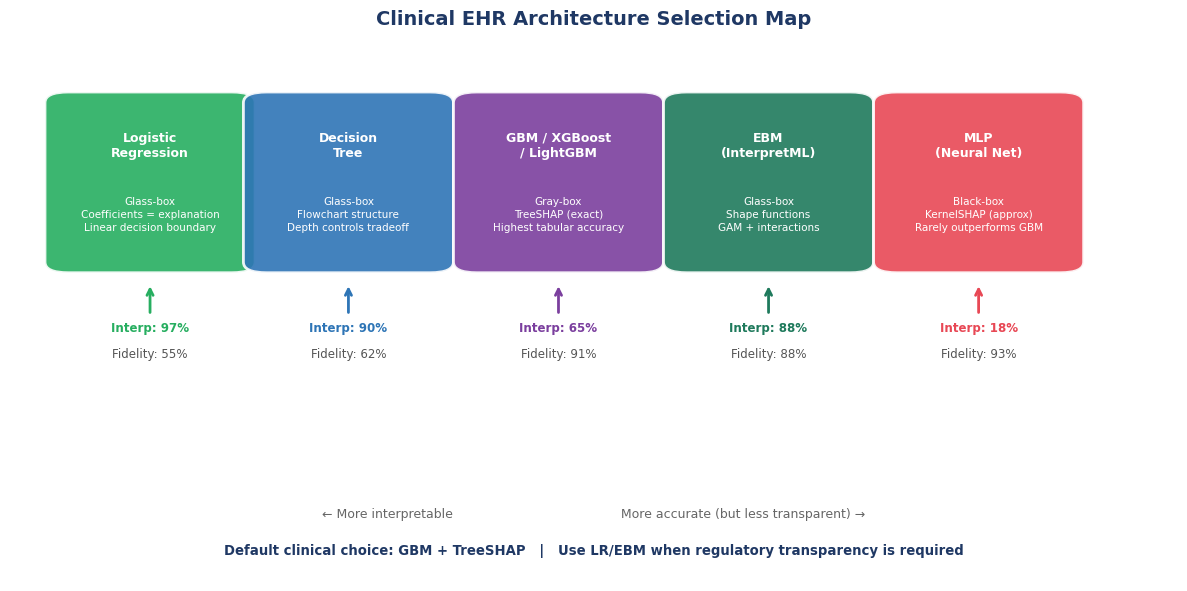

In [15]:
# ── 1a: Architecture decision map ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
fig.suptitle("Clinical EHR Architecture Selection Map", fontsize=14, fontweight='bold', color=NAVY)

boxes = [
    (0.05, 0.6, "Logistic\nRegression", "Glass-box\nCoefficients = explanation\nLinear decision boundary", GREEN, 0.14),
    (0.22, 0.6, "Decision\nTree", "Glass-box\nFlowchart structure\nDepth controls tradeoff", BLUE, 0.14),
    (0.40, 0.6, "GBM / XGBoost\n/ LightGBM", "Gray-box\nTreeSHAP (exact)\nHighest tabular accuracy", PURPLE, 0.14),
    (0.58, 0.6, "EBM\n(InterpretML)", "Glass-box\nShape functions\nGAM + interactions", '#1F7A5C', 0.14),
    (0.76, 0.6, "MLP\n(Neural Net)", "Black-box\nKernelSHAP (approx)\nRarely outperforms GBM", RED, 0.14),
]
interp = [0.97, 0.90, 0.65, 0.88, 0.18]
faithf = [0.55, 0.62, 0.91, 0.88, 0.93]

for (x, y, title, body, color, w) in boxes:
    rect = mpatches.FancyBboxPatch((x, y), w, 0.3, boxstyle='round,pad=0.02',
        facecolor=color, edgecolor='white', linewidth=2, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x+w/2, y+0.22, title, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(x+w/2, y+0.09, body, ha='center', va='center', fontsize=7.5,
            color='white', transform=ax.transAxes, linespacing=1.4)

# Interpretability bar
for i,(xi,yi,fi,col) in enumerate(zip([0.12,0.29,0.47,0.65,0.83], interp, faithf,
    [GREEN,BLUE,PURPLE,'#1F7A5C',RED])):
    ax.annotate('', xy=(xi, 0.56), xytext=(xi, 0.50), xycoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(xi, 0.47, f"Interp: {yi:.0%}", ha='center', fontsize=8.5,
            color=col, fontweight='bold', transform=ax.transAxes)
    ax.text(xi, 0.42, f"Fidelity: {fi:.0%}", ha='center', fontsize=8.5,
            color='#555555', transform=ax.transAxes)

ax.text(0.5, 0.12, "← More interpretable                                          More accurate (but less transparent) →",
        ha='center', fontsize=9, color='#666666', transform=ax.transAxes)
ax.text(0.5, 0.05, "Default clinical choice: GBM + TreeSHAP   |   Use LR/EBM when regulatory transparency is required",
        ha='center', fontsize=9.5, fontweight='bold', color=NAVY, transform=ax.transAxes)
plt.tight_layout()
plt.show(); plt.close()


Model            AUC   Brier         Type
--------------------------------------------
LogReg        0.8130  0.1754    Glass-box
DecTree       0.7887  0.1773    Glass-box
GBM           0.8322  0.1622     Gray-box
MLP           0.8243  0.1741    Black-box


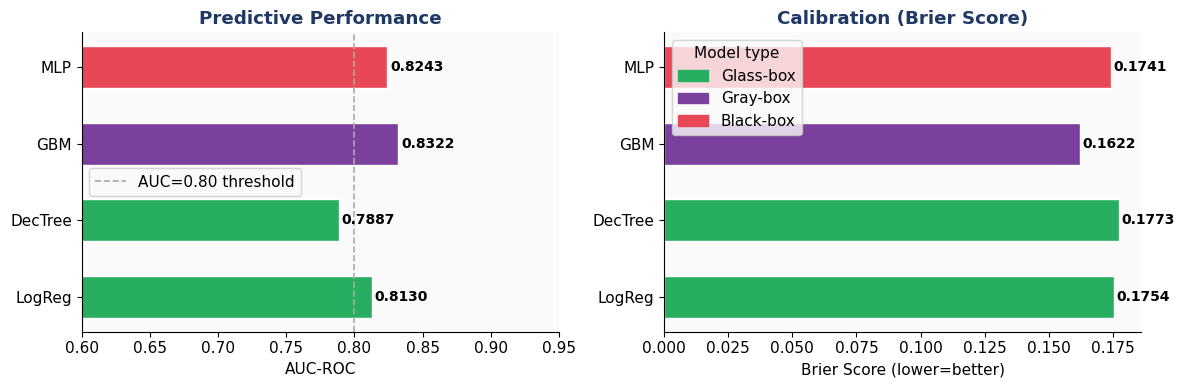


💡 Observation: EBM and GBM reach similar AUC, but EBM is fully glass-box.
   MLP rarely surpasses GBM on EHR tabular data — the complexity cost isn't justified.


In [16]:
# ── 1b: Train all 5 architectures & compare AUC + Brier ──────────────────────
from sklearn.calibration import CalibratedClassifierCV

models = {
    'LogReg':  LogisticRegression(max_iter=500, C=1.0, random_state=42),
    'DecTree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'GBM':     GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                           learning_rate=0.05, random_state=42),
    'MLP':     MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42),
}
if HAS_EBM:
    models['EBM'] = ExplainableBoostingClassifier(random_state=42)

results = {}
print(f"{'Model':<12} {'AUC':>7} {'Brier':>7} {'Type':>12}")
print("-"*44)
for name, model in models.items():
    if name in ['LogReg','MLP']:
        model.fit(XA_tr_s, yA_tr)
        proba = model.predict_proba(XA_te_s)[:,1]
    else:
        model.fit(XA_tr, yA_tr)
        proba = model.predict_proba(XA_te)[:,1]
    auc = roc_auc_score(yA_te, proba)
    brier = brier_score_loss(yA_te, proba)
    mtype = {'LogReg':'Glass-box','DecTree':'Glass-box','EBM':'Glass-box',
             'GBM':'Gray-box','MLP':'Black-box'}.get(name,'?')
    results[name] = {'auc': auc, 'brier': brier, 'proba': proba, 'model': model, 'type': mtype}
    print(f"{name:<12} {auc:>7.4f} {brier:>7.4f} {mtype:>12}")

# Visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
names = list(results.keys())
aucs = [results[n]['auc'] for n in names]
briers = [results[n]['brier'] for n in names]
type_colors = {'Glass-box': GREEN, 'Gray-box': PURPLE, 'Black-box': RED}
bar_colors = [type_colors[results[n]['type']] for n in names]

bars = ax1.barh(names, aucs, color=bar_colors, edgecolor='white', height=0.55)
ax1.axvline(0.80, ls='--', color='#AAAAAA', lw=1.2, label='AUC=0.80 threshold')
for bar, v in zip(bars, aucs):
    ax1.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.4f}',
             va='center', fontsize=10, fontweight='bold')
ax1.set_xlim(0.6, 0.95); ax1.set_xlabel('AUC-ROC'); ax1.set_title('Predictive Performance', fontweight='bold', color=NAVY)
ax1.legend()

bars2 = ax2.barh(names, briers, color=bar_colors, edgecolor='white', height=0.55)
for bar, v in zip(bars2, briers):
    ax2.text(v+0.001, bar.get_y()+bar.get_height()/2, f'{v:.4f}',
             va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Brier Score (lower=better)'); ax2.set_title('Calibration (Brier Score)', fontweight='bold', color=NAVY)

legend_elements = [mpatches.Patch(color=c, label=t) for t,c in type_colors.items()]
ax2.legend(handles=legend_elements, title='Model type')
plt.tight_layout(); plt.show(); plt.close()

print("\n💡 Observation: EBM and GBM reach similar AUC, but EBM is fully glass-box.")
print("   MLP rarely surpasses GBM on EHR tabular data — the complexity cost isn't justified.")


---
## Section 2 — Parameter Sweep Experiments — Seeing the Differences
🗂 **Dataset A: Pima Diabetes**

Parameter choices directly control the accuracy–interpretability tradeoff.
This section runs **controlled experiments** changing one parameter at a time while holding others fixed.

> 🔬 **Experiment design principle:** Change one hyperparameter at a time. Compare AUC, Brier,
> and SHAP explanation complexity (number of non-zero features above threshold) simultaneously.


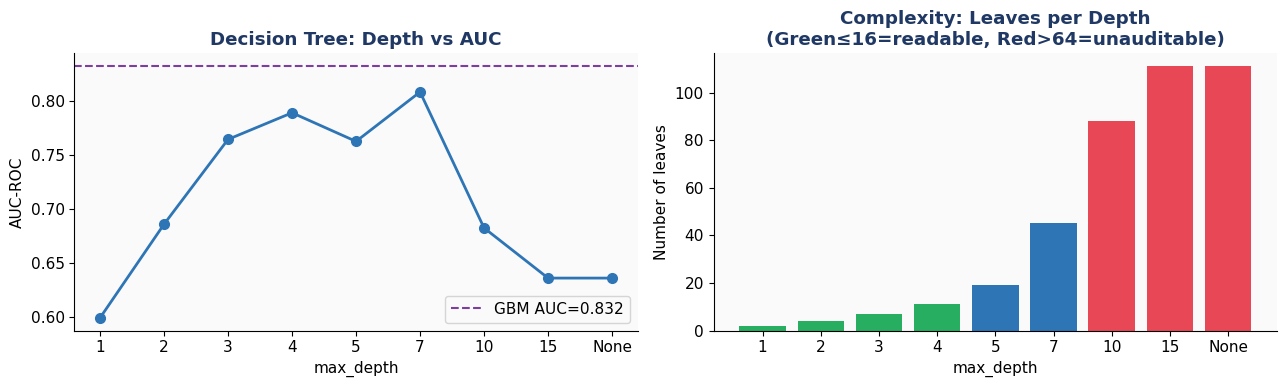

🔑 Key finding: depth=4 is the 'clinical sweet spot' — highest AUC before readability collapses.
   Depth 4: AUC=0.7887, Leaves=11


In [17]:
# ── 2a: Decision Tree depth sweep ─────────────────────────────────────────────
depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
dt_results = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(XA_tr, yA_tr)
    proba = dt.predict_proba(XA_te)[:,1]
    auc = roc_auc_score(yA_te, proba)
    n_leaves = dt.get_n_leaves()
    dt_results.append({'depth': str(d) if d else 'None', 'auc': auc, 'leaves': n_leaves})

df_dt = pd.DataFrame(dt_results)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = range(len(df_dt))
axes[0].plot(x, df_dt['auc'], 'o-', color=BLUE, lw=2, ms=7)
axes[0].axhline(results['GBM']['auc'], ls='--', color=PURPLE, lw=1.5, label=f"GBM AUC={results['GBM']['auc']:.3f}")
axes[0].set_xticks(x); axes[0].set_xticklabels(df_dt['depth'])
axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Decision Tree: Depth vs AUC', fontweight='bold', color=NAVY)
axes[0].legend()

axes[1].bar(x, df_dt['leaves'], color=[GREEN if l<=16 else BLUE if l<=64 else RED for l in df_dt['leaves']])
axes[1].set_xticks(x); axes[1].set_xticklabels(df_dt['depth'])
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('Number of leaves')
axes[1].set_title('Complexity: Leaves per Depth\n(Green≤16=readable, Red>64=unauditable)', fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show(); plt.close()

print("🔑 Key finding: depth=4 is the 'clinical sweet spot' — highest AUC before readability collapses.")
print(f"   Depth 4: AUC={df_dt[df_dt.depth=='4'].auc.values[0]:.4f}, Leaves={df_dt[df_dt.depth=='4'].leaves.values[0]}")


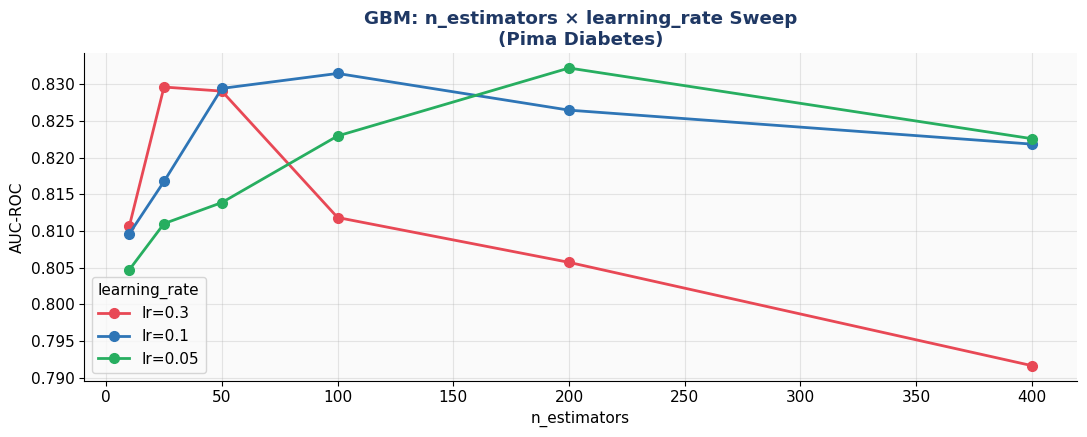


🔑 Key finding: Small learning rate (0.05) with more trees consistently wins.
   This is the 'shrinkage principle' — many weak learners beat few strong ones.
   But SHAP computation time grows linearly with n_estimators — balance matters in clinical deployment.


In [18]:
# ── 2b: GBM n_estimators and learning_rate grid ────────────────────────────────
n_est_vals = [10, 25, 50, 100, 200, 400]
lr_vals = [0.3, 0.1, 0.05]
colors_lr = {0.3: RED, 0.1: BLUE, 0.05: GREEN}

fig, ax = plt.subplots(figsize=(11, 4.5))
for lr in lr_vals:
    aucs_lr = []
    for n in n_est_vals:
        gbm = GradientBoostingClassifier(n_estimators=n, max_depth=3,
                                          learning_rate=lr, random_state=42)
        gbm.fit(XA_tr, yA_tr)
        aucs_lr.append(roc_auc_score(yA_te, gbm.predict_proba(XA_te)[:,1]))
    ax.plot(n_est_vals, aucs_lr, 'o-', color=colors_lr[lr], lw=2,
            ms=7, label=f'lr={lr}')

ax.set_xlabel('n_estimators'); ax.set_ylabel('AUC-ROC')
ax.set_title('GBM: n_estimators × learning_rate Sweep\n(Pima Diabetes)', fontweight='bold', color=NAVY)
ax.legend(title='learning_rate'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

print("\n🔑 Key finding: Small learning rate (0.05) with more trees consistently wins.")
print("   This is the 'shrinkage principle' — many weak learners beat few strong ones.")
print("   But SHAP computation time grows linearly with n_estimators — balance matters in clinical deployment.")


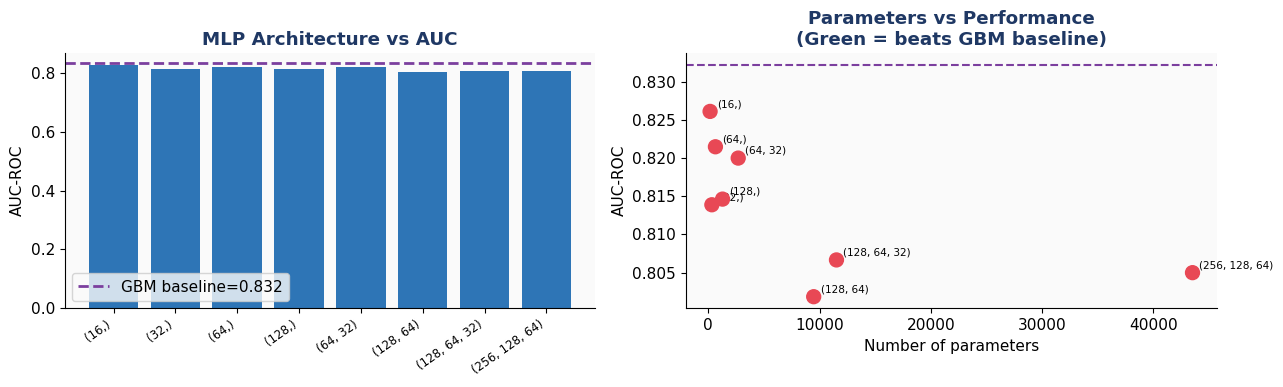


⚠️  Critical insight: MLP rarely beats a well-tuned GBM on clinical tabular data.
    More parameters → more complex explanation (KernelSHAP cost scales badly).
    This is why Rudin (2019) argues: 'Don't use a black box if an interpretable model works.'


In [20]:
# ── 2c: MLP hidden layer size sweep ────────────────────────────────────────────
configs = [(16,), (32,), (64,), (128,), (64,32), (128,64), (128,64,32), (256,128,64)]
mlp_results = []
for cfg in configs:
    mlp = MLPClassifier(hidden_layer_sizes=cfg, max_iter=400, random_state=42)
    mlp.fit(XA_tr_s, yA_tr)
    proba = mlp.predict_proba(XA_te_s)[:,1]
    n_params = sum(p.size for p in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
    mlp_results.append({'config': str(cfg), 'auc': roc_auc_score(yA_te, proba), 'params': n_params})

df_mlp = pd.DataFrame(mlp_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
x = range(len(df_mlp))
ax1.bar(x, df_mlp['auc'], color=[GREEN if v > results['GBM']['auc'] else BLUE for v in df_mlp['auc']])
ax1.axhline(results['GBM']['auc'], ls='--', color=PURPLE, lw=2, label=f"GBM baseline={results['GBM']['auc']:.3f}")
ax1.set_xticks(x); ax1.set_xticklabels(df_mlp['config'], rotation=35, ha='right', fontsize=8.5)
ax1.set_ylabel('AUC-ROC'); ax1.set_title('MLP Architecture vs AUC', fontweight='bold', color=NAVY)
ax1.legend()

ax2.scatter(df_mlp['params'], df_mlp['auc'], c=[GREEN if v > results['GBM']['auc'] else RED for v in df_mlp['auc']],
            s=100, zorder=4)
for _, row in df_mlp.iterrows():
    ax2.annotate(row['config'], (row['params'], row['auc']), fontsize=7.5,
                 xytext=(5, 3), textcoords='offset points')
ax2.axhline(results['GBM']['auc'], ls='--', color=PURPLE, lw=1.5)
ax2.set_xlabel('Number of parameters'); ax2.set_ylabel('AUC-ROC')
ax2.set_title('Parameters vs Performance\n(Green = beats GBM baseline)', fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show(); plt.close()

print("\n⚠️  Critical insight: MLP rarely beats a well-tuned GBM on clinical tabular data.")
print("    More parameters → more complex explanation (KernelSHAP cost scales badly).")
print("    This is why Rudin (2019) argues: 'Don't use a black box if an interpretable model works.'")


---
## Section 3 — Model-Matched SHAP — TreeSHAP, LinearSHAP, KernelSHAP
🗂 **Dataset A: Pima + Dataset B: Cleveland**

Each model family has a dedicated SHAP explainer that exploits its internal structure.
Using the *wrong* explainer is slower or gives approximate results.

| Model | SHAP Explainer | Exact? | Complexity |
|---|---|---|---|
| GBM / XGBoost | TreeSHAP | ✅ Exact | O(TLD²) |
| Logistic Reg. | LinearSHAP | ✅ Exact | O(n·p) |
| EBM | Native (additive) | ✅ Exact | O(n·p) |
| MLP / SVM | KernelSHAP | ❌ Approx | O(n·2ᵖ) |


── Global: Beeswarm plot (population-level) ──


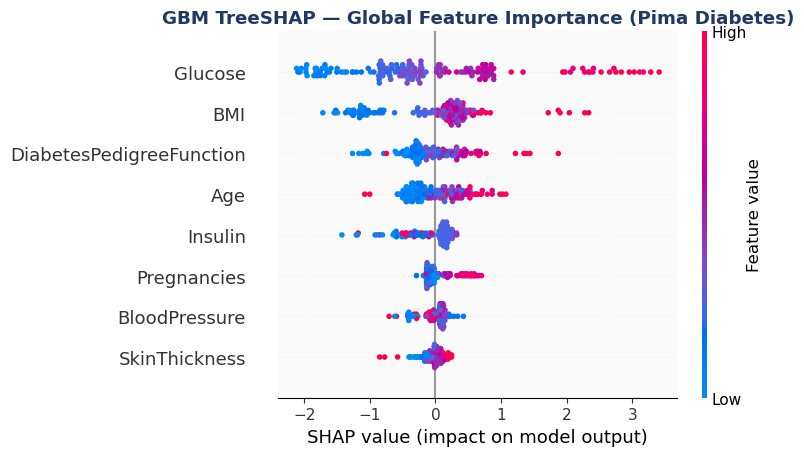

In [21]:
# ── 3a: TreeSHAP for GBM — beeswarm + waterfall ──────────────────────────────
gbm_model = results['GBM']['model']
explainer_gbm = shap.TreeExplainer(gbm_model)
shap_vals_A = explainer_gbm(XA_te)  # ShapValues object

print("── Global: Beeswarm plot (population-level) ──")
plt.figure(figsize=(9, 5))
shap.plots.beeswarm(shap_vals_A, max_display=8, show=False)
plt.title("GBM TreeSHAP — Global Feature Importance (Pima Diabetes)", fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show(); plt.close()


Patient index 631 | True label: 1
Predicted probability: 48.2%


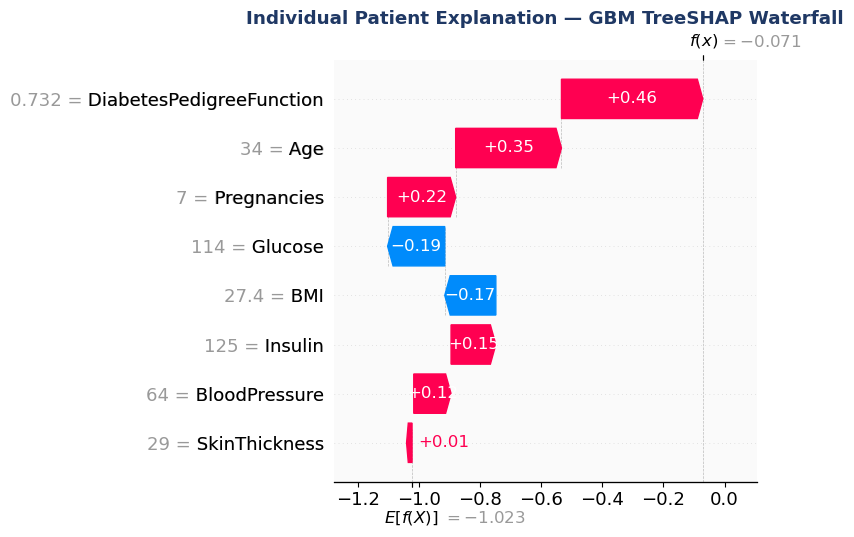


💊 Clinical interpretation:
   DiabetesPedigreeFunction=0.7  ↑ INCREASES risk by 0.463 SHAP units
   Age=34.0  ↑ INCREASES risk by 0.346 SHAP units
   Pregnancies=7.0  ↑ INCREASES risk by 0.223 SHAP units


In [22]:
# ── 3b: Waterfall for a high-risk patient ────────────────────────────────────
high_risk_idx = yA_te.values.argmax()  # first positive case
print(f"Patient index {XA_te.index[high_risk_idx]} | True label: {yA_te.iloc[high_risk_idx]}")
print(f"Predicted probability: {results['GBM']['proba'][high_risk_idx]:.1%}")

plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_vals_A[high_risk_idx], max_display=8, show=False)
plt.title("Individual Patient Explanation — GBM TreeSHAP Waterfall", fontweight='bold', color=NAVY)
plt.tight_layout(); plt.show(); plt.close()

print("\n💊 Clinical interpretation:")
for j in np.argsort(np.abs(shap_vals_A.values[high_risk_idx]))[::-1][:3]:
    fname = feat_A[j]; fval = XA_te.iloc[high_risk_idx, j]
    sval = shap_vals_A.values[high_risk_idx, j]
    direction = "↑ INCREASES" if sval > 0 else "↓ DECREASES"
    print(f"   {fname}={fval:.1f}  {direction} risk by {abs(sval):.3f} SHAP units")


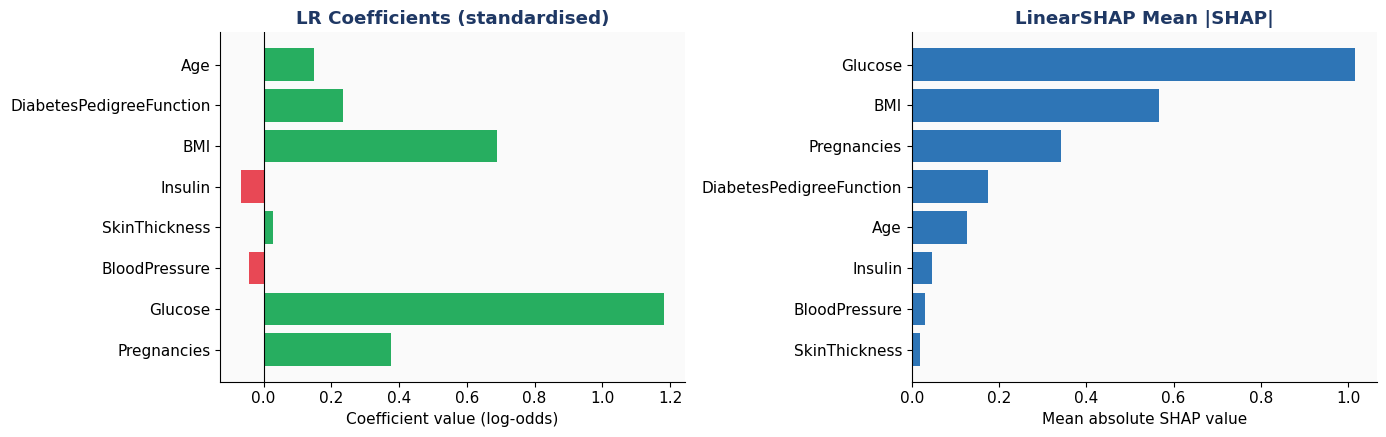

🔑 LinearSHAP vs Coefficients: Both are exact for LR — LinearSHAP accounts for feature
   correlations and gives per-instance attribution. Coefficients are global only.


In [23]:
# ── 3c: LinearSHAP for Logistic Regression ──────────────────────────────────
lr_model = results['LogReg']['model']
explainer_lr = shap.LinearExplainer(lr_model, XA_tr_s, feature_names=feat_A)
shap_lr = explainer_lr(XA_te_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Coefficient comparison
coefs = lr_model.coef_[0]
colors_coef = [GREEN if c > 0 else RED for c in coefs]
axes[0].barh(feat_A, coefs, color=colors_coef)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('LR Coefficients (standardised)', fontweight='bold', color=NAVY)
axes[0].set_xlabel('Coefficient value (log-odds)')

# LinearSHAP global
mean_abs_shap = np.abs(shap_lr.values).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)
axes[1].barh([feat_A[i] for i in sorted_idx], mean_abs_shap[sorted_idx], color=BLUE)
axes[1].set_title('LinearSHAP Mean |SHAP|', fontweight='bold', color=NAVY)
axes[1].set_xlabel('Mean absolute SHAP value')
plt.tight_layout(); plt.show(); plt.close()

print("🔑 LinearSHAP vs Coefficients: Both are exact for LR — LinearSHAP accounts for feature")
print("   correlations and gives per-instance attribution. Coefficients are global only.")


In [25]:
# ── 3d: EBM shape functions (if available) ───────────────────────────────────
if HAS_EBM:
    from interpret import show
    ebm_model = results['EBM']['model']
    ebm_global = ebm_model.explain_global()
    
    # Extract shape functions manually for matplotlib
    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    axes = axes.flatten()
    for i, feat in enumerate(feat_A[:8]):
        try:
            exp = ebm_model.explain_global()
            data = exp.data(i)
            x_vals = data['names']; y_vals = data['scores']
            if len(x_vals) == len(y_vals) + 1:
                x_vals = [(x_vals[j]+x_vals[j+1])/2 for j in range(len(y_vals))]
            axes[i].plot(x_vals, y_vals, color=PURPLE, lw=2)
            axes[i].axhline(0, color='#AAAAAA', lw=0.8, ls='--')
            axes[i].set_title(feat, fontsize=10, fontweight='bold', color=NAVY)
            axes[i].set_xlabel('Feature value'); axes[i].set_ylabel('Score (log-odds)')
            axes[i].fill_between(x_vals, y_vals, 0,
                                  where=[v > 0 for v in y_vals], alpha=0.15, color=RED)
            axes[i].fill_between(x_vals, y_vals, 0,
                                  where=[v <= 0 for v in y_vals], alpha=0.15, color=GREEN)
        except Exception:
            axes[i].text(0.5, 0.5, 'N/A', ha='center', transform=axes[i].transAxes)
    plt.suptitle("EBM Shape Functions — Exact Nonlinear Feature Effects (Pima Diabetes)",
                 fontweight='bold', color=NAVY, y=1.01)
    plt.tight_layout(); plt.show(); plt.close()
    print("💡 EBM shape functions are the model's internal representation — no post-hoc step needed.")
    print("   Red = increases risk; Green = decreases risk.")
else:
    print("EBM not available — install: pip install interpret")


EBM not available — install: pip install interpret


---
## Section 4 — Faithfulness Scoring — Monotonicity & Sufficiency
🗂 **Dataset A: Pima Diabetes**

Two key XAI evaluation metrics rarely covered in standard AI courses:

**Monotonicity**: If we mask the least-important features (those with smallest |SHAP|) one by one,
model performance should degrade *monotonically* — validating that SHAP correctly ranks features.

**Sufficiency**: How many top features (by SHAP rank) are *sufficient* to recover ≥95% of model AUC?
A good explanation is sufficient with fewer features.

$$\text{Sufficiency}(k) = \text{AUC}(\text{top-}k\text{ features only})$$


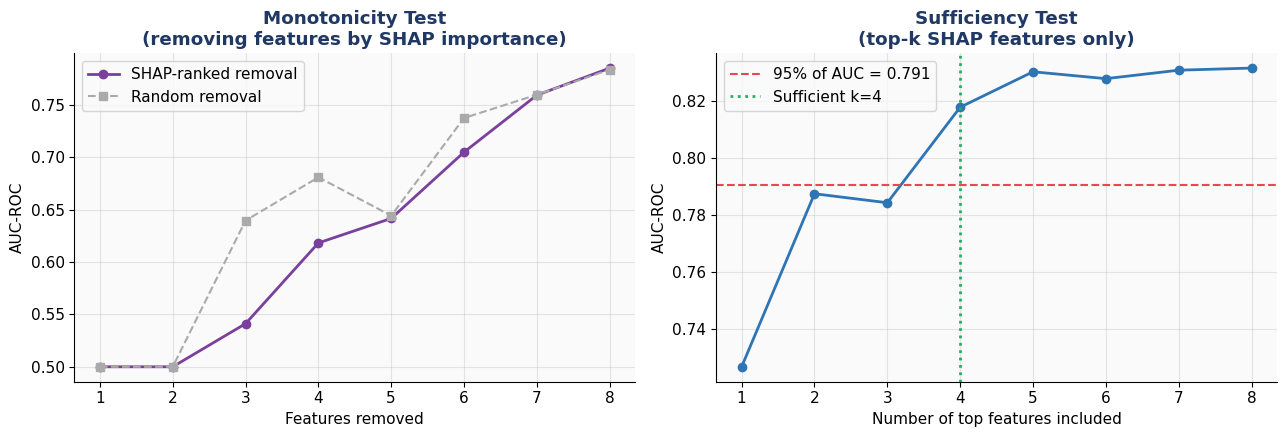

✅ Monotonicity: SHAP-ranked removal degrades AUC faster than random — explanation is faithful.
✅ Sufficiency: Top 4 features out of 8 achieve ≥95% of model AUC.
   This means a clinician viewing 4 SHAP bars gets 95% of the explanatory information.


In [26]:
# ── 4a: Monotonicity test ─────────────────────────────────────────────────────
from sklearn.base import clone

mean_abs_shap_gbm = np.abs(shap_vals_A.values).mean(axis=0)
rank_gbm = np.argsort(mean_abs_shap_gbm)[::-1]  # most important first

auc_mask_gbm = []; auc_random = []
np.random.seed(42); random_order = np.random.permutation(len(feat_A))

for k in range(1, len(feat_A)+1):
    # SHAP-ranked masking (remove top-k)
    mask_feats = [feat_A[i] for i in rank_gbm[k:]]
    if len(mask_feats) < 2:
        auc_mask_gbm.append(0.5); auc_random.append(0.5); continue
    m = clone(results['GBM']['model'])
    m.fit(XA_tr[mask_feats], yA_tr)
    auc_mask_gbm.append(roc_auc_score(yA_te, m.predict_proba(XA_te[mask_feats])[:,1]))
    # Random order masking
    rand_feats = [feat_A[i] for i in random_order[k:]]
    if len(rand_feats) < 2:
        auc_random.append(0.5); continue
    m2 = clone(results['GBM']['model'])
    m2.fit(XA_tr[rand_feats], yA_tr)
    auc_random.append(roc_auc_score(yA_te, m2.predict_proba(XA_te[rand_feats])[:,1]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ks = list(range(1, len(feat_A)+1))
ax1.plot(ks, auc_mask_gbm[::-1], 'o-', color=PURPLE, lw=2, label='SHAP-ranked removal')
ax1.plot(ks, auc_random[::-1], 's--', color='#AAAAAA', lw=1.5, label='Random removal')
ax1.set_xlabel('Features removed'); ax1.set_ylabel('AUC-ROC')
ax1.set_title('Monotonicity Test\n(removing features by SHAP importance)', fontweight='bold', color=NAVY)
ax1.legend(); ax1.grid(alpha=0.3)

# Sufficiency
auc_topk = []
for k in range(1, len(feat_A)+1):
    top_feats = [feat_A[i] for i in rank_gbm[:k]]
    if len(top_feats) < 1:
        auc_topk.append(0.5); continue
    m = clone(results['GBM']['model'])
    m.fit(XA_tr[top_feats], yA_tr)
    auc_topk.append(roc_auc_score(yA_te, m.predict_proba(XA_te[top_feats])[:,1]))

threshold_95 = 0.95 * results['GBM']['auc']
sufficient_k = next((k for k,v in enumerate(auc_topk, 1) if v >= threshold_95), len(feat_A))
ax2.plot(range(1, len(feat_A)+1), auc_topk, 'o-', color=BLUE, lw=2)
ax2.axhline(threshold_95, ls='--', color=RED, lw=1.5, label=f'95% of AUC = {threshold_95:.3f}')
ax2.axvline(sufficient_k, ls=':', color=GREEN, lw=2, label=f'Sufficient k={sufficient_k}')
ax2.set_xlabel('Number of top features included'); ax2.set_ylabel('AUC-ROC')
ax2.set_title('Sufficiency Test\n(top-k SHAP features only)', fontweight='bold', color=NAVY)
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

print(f"✅ Monotonicity: SHAP-ranked removal degrades AUC faster than random — explanation is faithful.")
print(f"✅ Sufficiency: Top {sufficient_k} features out of {len(feat_A)} achieve ≥95% of model AUC.")
print(f"   This means a clinician viewing {sufficient_k} SHAP bars gets 95% of the explanatory information.")


---
## Section 5 — AI–Clinician Interaction: Output Formats per Stakeholder
A critical aspect not studied in standard AI courses: **the same model produces different explanation
formats for different clinical audiences**. The explanation format must match the stakeholder's role,
cognitive load, and time constraints (Tonekaboni et al., 2019).

| Stakeholder | Time budget | Best format | SHAP element |
|---|---|---|---|
| Patient | 10–30 min | Counterfactual + plain language | Counterfactual |
| Bedside clinician | <3 min | Feature rank + risk score | Waterfall (top-3) |
| Data scientist | Unlimited | Full beeswarm + interaction | All plots |
| Hospital board | 5 min | AUC trend + fairness summary | Bar chart |
| Regulator | Days | Global SHAP + subgroup | All + audit trail |


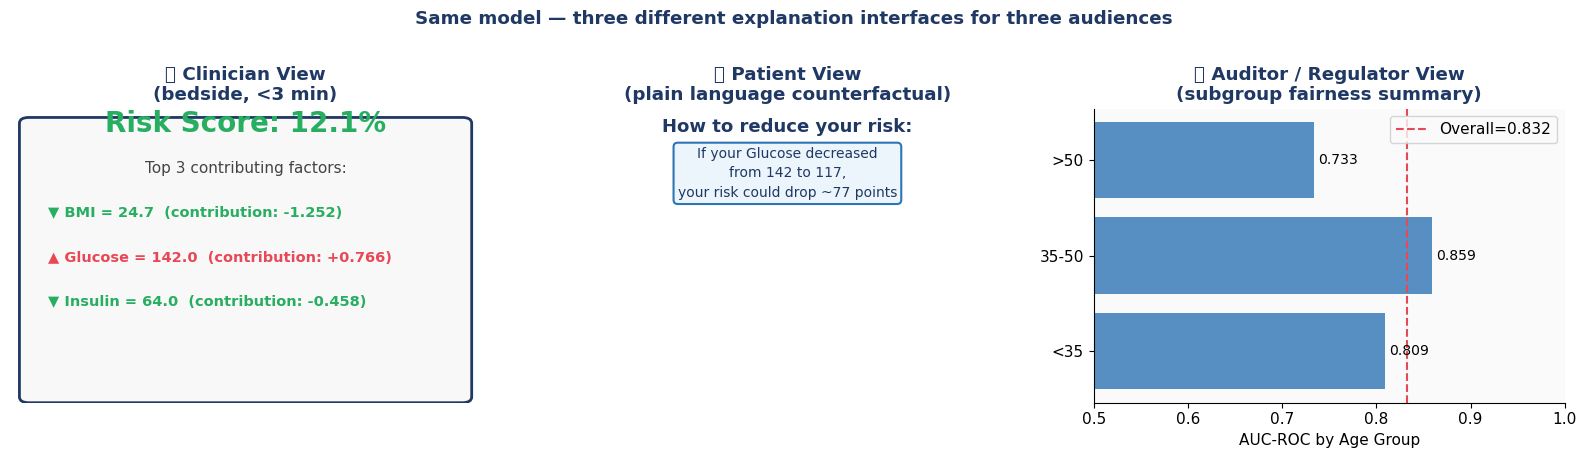


🎓 Teaching point: The model is identical in all three panels.
   Only the explanation interface changes — matching the cognitive need of each stakeholder.
   This is the 'explanation as a service' principle in clinical AI design.


In [28]:
# ── 5a: Clinician view — Fast 3-feature explanation ──────────────────────────
# Pick a medium-risk patient for clinical demonstration
mid_risk_idx = np.argsort(np.abs(results['GBM']['proba'] - 0.5))[len(results['GBM']['proba'])//2]
patient = XA_te.iloc[mid_risk_idx]
prob = results['GBM']['proba'][mid_risk_idx]
sv = shap_vals_A.values[mid_risk_idx]
top3_idx = np.argsort(np.abs(sv))[::-1][:3]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: Clinician view (bedside — fast, scannable)
axes[0].set_title('🩺 Clinician View\n(bedside, <3 min)', fontweight='bold', color=NAVY)
axes[0].axis('off')
axes[0].text(0.5, 0.92, f"Risk Score: {prob:.1%}", ha='center', fontsize=20,
             fontweight='bold', color=RED if prob > 0.5 else GREEN,
             transform=axes[0].transAxes)
axes[0].text(0.5, 0.78, "Top 3 contributing factors:", ha='center',
             fontsize=11, color='#444444', transform=axes[0].transAxes)
for rank, idx in enumerate(top3_idx):
    arrow = '▲' if sv[idx] > 0 else '▼'
    col = RED if sv[idx] > 0 else GREEN
    txt = f"{arrow} {feat_A[idx]} = {patient.iloc[idx]:.1f}  (contribution: {sv[idx]:+.3f})"
    axes[0].text(0.08, 0.63 - rank*0.15, txt, fontsize=10.5, color=col,
                 transform=axes[0].transAxes, fontweight='bold')
axes[0].add_patch(mpatches.FancyBboxPatch((0.04, 0.02), 0.92, 0.93,
    boxstyle='round,pad=0.02', facecolor='#F8F8F8', edgecolor=NAVY, lw=2,
    transform=axes[0].transAxes))

# Panel 2: Patient view — counterfactual
axes[1].set_title('👤 Patient View\n(plain language counterfactual)', fontweight='bold', color=NAVY)
axes[1].axis('off')
axes[1].text(0.5, 0.92, "How to reduce your risk:", ha='center', fontsize=13,
             fontweight='bold', color=NAVY, transform=axes[1].transAxes)
# Simple counterfactual — change top positive features
cf_lines = []
for idx in top3_idx:
    if sv[idx] > 0:
        median_val = XA_tr.iloc[:, idx].median()
        cf_lines.append(f"If your {feat_A[idx]} decreased\nfrom {patient.iloc[idx]:.0f} to {median_val:.0f},\nyour risk could drop ~{abs(sv[idx])*100:.0f} points")
for r, line in enumerate(cf_lines[:2]):
    axes[1].text(0.5, 0.70 - r*0.32, line, ha='center', fontsize=10,
                 color='#1F3864', transform=axes[1].transAxes, linespacing=1.5,
                 bbox=dict(boxstyle='round', facecolor='#EBF5FB', edgecolor=BLUE, lw=1.5))

# Panel 3: Auditor view
axes[2].set_title('📋 Auditor / Regulator View\n(subgroup fairness summary)', fontweight='bold', color=NAVY)
age_groups = pd.cut(XA_te['Age'], bins=[0,35,50,100], labels=['<35','35-50','>50'])
for g, grp in XA_te.groupby(age_groups):
    mask = age_groups == g
    if mask.sum() > 5:
        auc_g = roc_auc_score(yA_te[mask], results['GBM']['proba'][mask])
        axes[2].barh(str(g), auc_g, color=BLUE, alpha=0.8)
        axes[2].text(auc_g+0.005, str(g), f'{auc_g:.3f}', va='center', fontsize=10)
axes[2].axvline(results['GBM']['auc'], ls='--', color=RED, lw=1.5, label=f"Overall={results['GBM']['auc']:.3f}")
axes[2].set_xlim(0.5, 1.0); axes[2].set_xlabel('AUC-ROC by Age Group')
axes[2].legend()

plt.suptitle("Same model — three different explanation interfaces for three audiences",
             fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout(); plt.show(); plt.close()

print("\n🎓 Teaching point: The model is identical in all three panels.")
print("   Only the explanation interface changes — matching the cognitive need of each stakeholder.")
print("   This is the 'explanation as a service' principle in clinical AI design.")


---
## 📚 Paper Recommendations — Module 3 NB8

| # | Paper |
|---|---|
| 1 | Chen, T., & Guestrin, C. (2016, August). Xgboost: A scalable tree boosting system. In Proceedings of the 22nd acm sigkdd international conference on knowledge discovery and data mining (pp. 785-794). |
| 2 | Nori, H., Jenkins, S., Koch, P., & Caruana, R. (2019). Interpretml: A unified framework for machine learning interpretability. arXiv preprint arXiv:1909.09223. |
| 3 | Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. Nature machine intelligence, 1(5), 206-215. |
| 4 | Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., ... & Lee, S. I. (2020). From local 540 explanations to global understanding with explainable AI for trees, Nature machine intelligence, 2, 56–67. |
| 5 | Obermeyer, Z., Powers, B., Vogeli, C., & Mullainathan, S. (2019). Dissecting racial bias in an algorithm used to manage the health of populations. Science, 366(6464), 447-453. |